In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
pd.set_option("display.max_columns", None)

In [22]:
df = pd.read_csv("flats_data_unianalysis.csv")
df.head()

,property_id,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
0,1,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,9.0,4.55,12.0,3264.0,1.0,1.0,1.0,13939.950980,1,1,1,1,1,1,1,0,0,0,135.0,37,3,New Property
1,1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.50,12.2,3318.4,1.0,1.0,NaN,13560.752170,1,1,0,0,1,1,0,0,0,1,150.0,31,3,New Property
2,1,Askari,3.0,4.0,https://www.zameen.com/Property/askari_11_aska...,NaN,3.55,10.0,2720.0,1.0,1.0,1.0,13051.470588,1,1,1,1,1,1,1,1,1,1,156.0,49,NaN,New Property
3,1,Askari,4.0,4.0,https://www.zameen.com/Property/askari_askari_...,NaN,4.45,7.6,2067.2,1.0,2.0,1.0,21526.702786,1,1,0,0,1,0,0,0,0,1,125.0,18,NaN,New Property
4,1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,10.0,4.65,12.2,3318.4,1.0,1.0,1.0,14012.777242,1,1,0,0,1,1,0,0,0,1,100.0,18,3,New Property


In [23]:
df.shape

(3118, 27)

In [24]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'link',
       'floors_in_building', 'price', 'area', 'area_sqft', 'servant_quarters',
       'kitchens', 'store_rooms', 'price_per_sqft', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

## Price

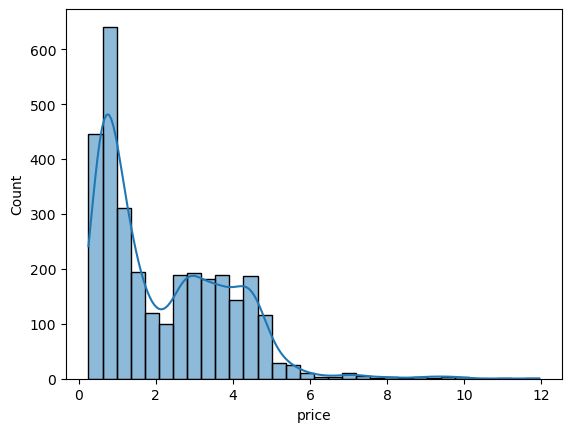

In [25]:
sns.histplot(df['price'], kde=True)  # distplot is deprecated
plt.show()

<Axes: xlabel='price'>

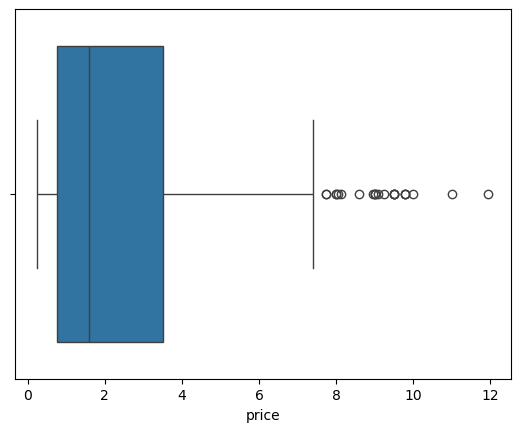

In [26]:
sns.boxplot(x=df['price'])

In [27]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Display number of outliers and stats
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(23,
 count    23.000000
 mean      9.170000
 std       1.022879
 min       7.740000
 25%       8.365000
 50%       9.100000
 75%       9.650000
 max      11.950000
 Name: price, dtype: float64)

In [28]:
outliers.sort_values('price', ascending=False).head(21)

,property_id,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
1730,1,Gulberg,3.0,3.0,https://www.zameen.com/Property/mm_alam_road_o...,NaN,11.95,14.4,3916.8,NaN,NaN,NaN,30509.599673,1,1,1,1,1,1,1,1,1,1,166.0,39,NaN,New Property
1543,1,Gulberg,9.0,6.0,https://www.zameen.com/Property/gulberg_main_b...,14.0,11.00,20.0,5440.0,1.0,2.0,1.0,20220.588235,1,1,1,1,1,1,1,1,1,1,181.0,49,7,Relatively New
2235,1,DHA Defence,3.0,4.0,https://www.zameen.com/Property/dha_defence_de...,11.0,10.00,10.0,2720.0,1.0,1.0,1.0,36764.705882,1,1,1,1,1,1,1,1,1,1,182.0,49,1,New Property
1566,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/gulberg_gulber...,NaN,9.80,10.5,2856.0,2.0,1.0,1.0,34313.725490,0,0,0,0,0,0,0,0,0,0,88.0,47,TRUE,New Property
1614,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/gulberg_gulber...,NaN,9.80,10.5,2856.0,NaN,NaN,NaN,34313.725490,0,0,0,0,0,0,0,0,0,0,78.0,47,NaN,Undefined
1563,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/gulberg_gulber...,NaN,9.80,10.5,2856.0,NaN,1.0,NaN,34313.725490,1,1,1,1,1,1,1,1,1,1,169.0,49,NaN,New Property
1797,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/mm_alam_road_o...,10.0,9.50,14.4,3916.8,NaN,NaN,NaN,24254.493464,1,1,1,1,1,1,1,1,1,1,186.0,49,8,Relatively New
2324,1,DHA Defence,3.0,4.0,https://www.zameen.com/Property/dha_defence_de...,12.0,9.50,10.0,2720.0,NaN,1.0,1.0,34926.470588,1,1,0,0,1,1,0,0,0,1,125.0,31,9,New Property
2345,1,DHA Defence,4.0,5.0,https://www.zameen.com/Property/dha_phase_5_pe...,NaN,9.50,13.1,3563.2,NaN,NaN,NaN,26661.427930,1,1,1,1,1,1,1,1,1,0,64.0,33,NaN,Undefined
2209,1,DHA Defence,3.0,3.0,https://www.zameen.com/Property/dha_defence_de...,NaN,9.50,11.7,3182.4,NaN,NaN,NaN,29851.684263,1,1,1,0,1,1,1,1,1,1,143.0,39,TRUE,Undefined


## outlier treatment done in price col

<Axes: xlabel='price'>

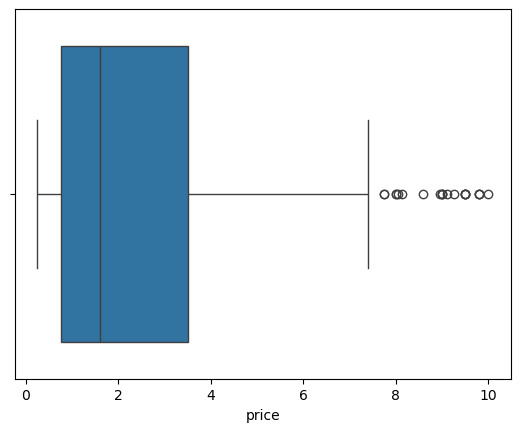

In [15]:
sns.boxplot(x=df['price'])

In [29]:
# Calculate the IQR for the 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]

# Display number of outliers and stats
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['price'].describe()

num_outliers, outliers_price_stats

(23,
 count    23.000000
 mean      9.170000
 std       1.022879
 min       7.740000
 25%       8.365000
 50%       9.100000
 75%       9.650000
 max      11.950000
 Name: price, dtype: float64)

In [30]:
outliers.sort_values('price', ascending=False).head(21)

,property_id,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
1730,1,Gulberg,3.0,3.0,https://www.zameen.com/Property/mm_alam_road_o...,NaN,11.95,14.4,3916.8,NaN,NaN,NaN,30509.599673,1,1,1,1,1,1,1,1,1,1,166.0,39,NaN,New Property
1543,1,Gulberg,9.0,6.0,https://www.zameen.com/Property/gulberg_main_b...,14.0,11.00,20.0,5440.0,1.0,2.0,1.0,20220.588235,1,1,1,1,1,1,1,1,1,1,181.0,49,7,Relatively New
2235,1,DHA Defence,3.0,4.0,https://www.zameen.com/Property/dha_defence_de...,11.0,10.00,10.0,2720.0,1.0,1.0,1.0,36764.705882,1,1,1,1,1,1,1,1,1,1,182.0,49,1,New Property
1566,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/gulberg_gulber...,NaN,9.80,10.5,2856.0,2.0,1.0,1.0,34313.725490,0,0,0,0,0,0,0,0,0,0,88.0,47,TRUE,New Property
1614,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/gulberg_gulber...,NaN,9.80,10.5,2856.0,NaN,NaN,NaN,34313.725490,0,0,0,0,0,0,0,0,0,0,78.0,47,NaN,Undefined
1563,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/gulberg_gulber...,NaN,9.80,10.5,2856.0,NaN,1.0,NaN,34313.725490,1,1,1,1,1,1,1,1,1,1,169.0,49,NaN,New Property
1797,1,Gulberg,3.0,4.0,https://www.zameen.com/Property/mm_alam_road_o...,10.0,9.50,14.4,3916.8,NaN,NaN,NaN,24254.493464,1,1,1,1,1,1,1,1,1,1,186.0,49,8,Relatively New
2324,1,DHA Defence,3.0,4.0,https://www.zameen.com/Property/dha_defence_de...,12.0,9.50,10.0,2720.0,NaN,1.0,1.0,34926.470588,1,1,0,0,1,1,0,0,0,1,125.0,31,9,New Property
2345,1,DHA Defence,4.0,5.0,https://www.zameen.com/Property/dha_phase_5_pe...,NaN,9.50,13.1,3563.2,NaN,NaN,NaN,26661.427930,1,1,1,1,1,1,1,1,1,0,64.0,33,NaN,Undefined
2209,1,DHA Defence,3.0,3.0,https://www.zameen.com/Property/dha_defence_de...,NaN,9.50,11.7,3182.4,NaN,NaN,NaN,29851.684263,1,1,1,0,1,1,1,1,1,1,143.0,39,TRUE,Undefined


## price_per_sqft

<Axes: xlabel='price_per_sqft', ylabel='Count'>

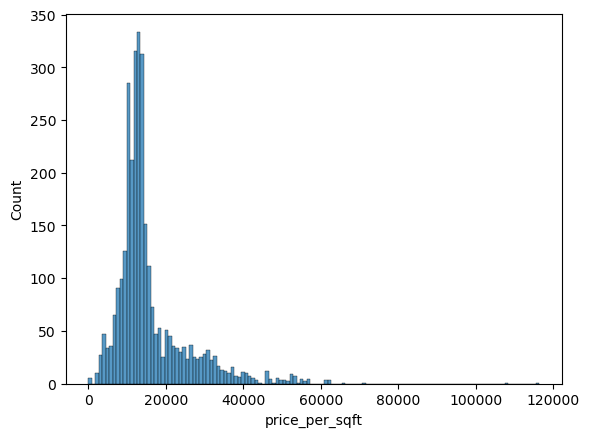

In [31]:
sns.histplot(df["price_per_sqft"])


<Axes: xlabel='price_per_sqft'>

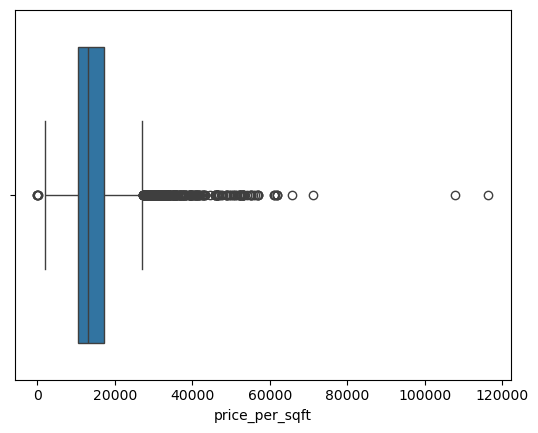

In [32]:
sns.boxplot(x=df["price_per_sqft"])

In [55]:
# Calculate IQR for price_per_sqft
Q1 = df["price_per_sqft"].quantile(0.25)
Q3 = df["price_per_sqft"].quantile(0.75)
IQR = Q3 - Q1

# Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Outliers
outliers_sqft = df[(df["price_per_sqft"] < lower_bound) | (df["price_per_sqft"] > upper_bound)]

# Count + stats
num_outliers = outliers_sqft.shape[0]
outliers_sqft_stats = outliers_sqft["price_per_sqft"].describe()

num_outliers, outliers_sqft_stats


(376,
 count      376.000000
 mean     35017.972826
 std       8762.281814
 min         27.941176
 25%      29618.383328
 50%      32952.691259
 75%      39423.581933
 max      57058.823529
 Name: price_per_sqft, dtype: float64)

In [49]:
df[df["price_per_sqft"] > 60000].shape

(8, 27)

In [50]:
df.shape

(3116, 27)

In [53]:
df = df[df["price_per_sqft"] <= 60000]

<Axes: xlabel='price_per_sqft'>

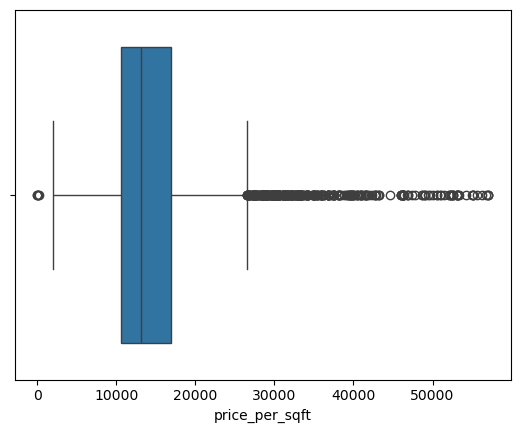

In [54]:
sns.boxplot(x=df["price_per_sqft"])

## area

<Axes: xlabel='area_sqft', ylabel='Count'>

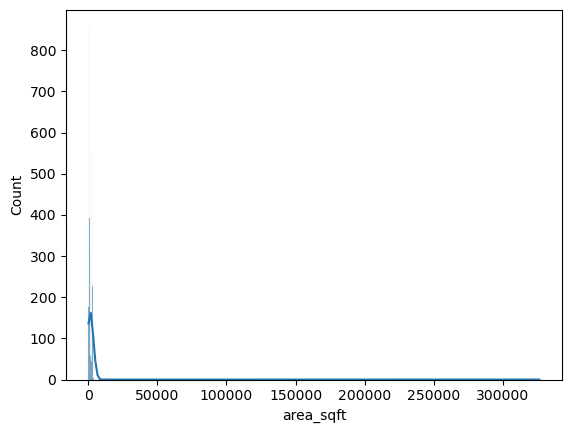

In [56]:
sns.histplot(df["area_sqft"], kde=True)

<Axes: xlabel='area_sqft'>

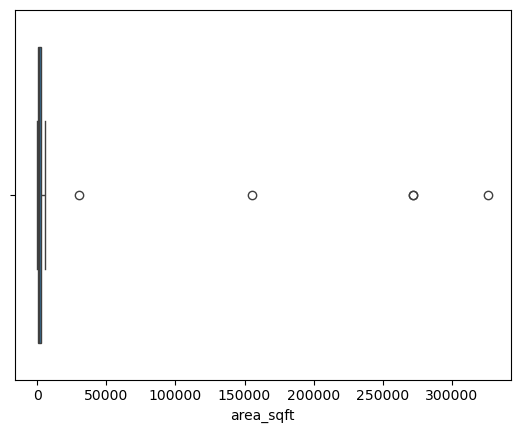

In [57]:
sns.boxplot(x=df["area_sqft"])


In [61]:
# Calculate the IQR for the 'price' column
Q1 = df['area_sqft'].quantile(0.25)
Q3 = df['area_sqft'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df[(df['area_sqft'] < lower_bound) | (df['area_sqft'] > upper_bound)]

# Display number of outliers and stats
num_outliers = outliers.shape[0]
outliers_price_stats = outliers['area_sqft'].describe()

num_outliers, outliers_price_stats

(5,
 count         5.0000
 mean     211180.8000
 std      118831.5672
 min       30464.0000
 25%      155040.0000
 50%      272000.0000
 75%      272000.0000
 max      326400.0000
 Name: area_sqft, dtype: float64)

In [62]:
Q1 = df["area_sqft"].quantile(0.25)
Q3 = df["area_sqft"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df["area_sqft"] >= lower_bound) & (df["area_sqft"] <= upper_bound)].copy()


In [63]:
df['area_sqft'].describe()

count    3103.000000
mean     1538.759136
std      1062.049528
min       108.800000
25%       598.400000
50%      1115.200000
75%      2720.000000
max      5440.000000
Name: area_sqft, dtype: float64

<Axes: xlabel='area_sqft'>

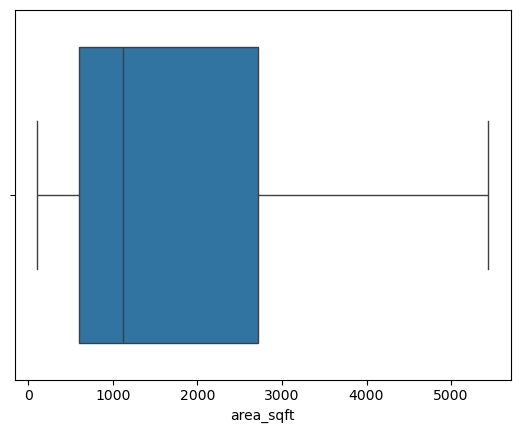

In [64]:
sns.boxplot(x=df["area_sqft"])


<Axes: xlabel='area_sqft', ylabel='Count'>

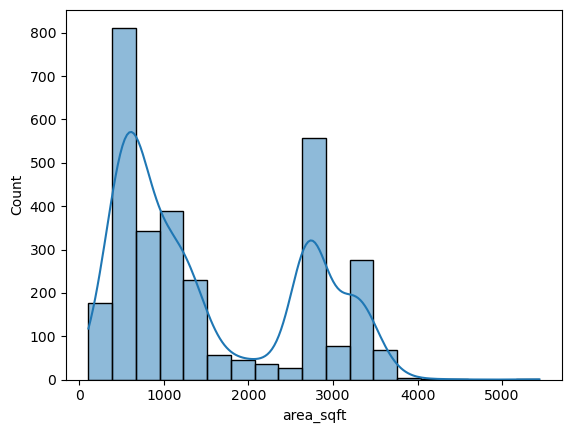

In [65]:
sns.histplot(df["area_sqft"], kde=True)

In [66]:
df.shape

(3103, 27)

In [67]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'link',
       'floors_in_building', 'price', 'area', 'area_sqft', 'servant_quarters',
       'kitchens', 'store_rooms', 'price_per_sqft', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

## bedrooms

<Axes: xlabel='bedrooms', ylabel='Count'>

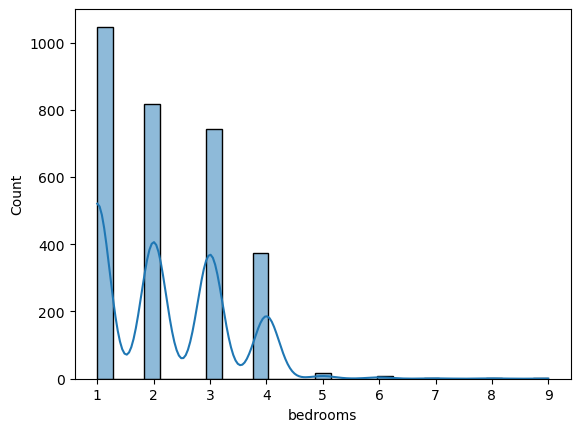

In [68]:
sns.histplot(df["bedrooms"], kde=True)

<Axes: xlabel='bedrooms'>

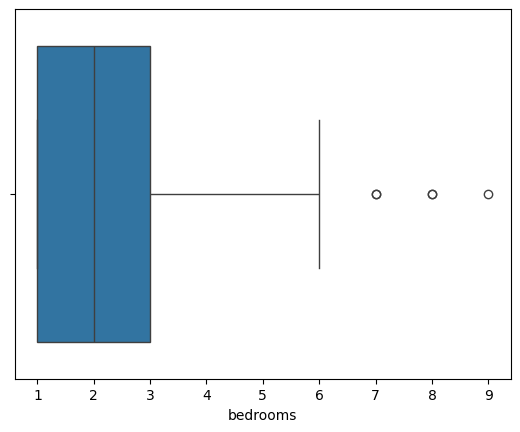

In [69]:
sns.boxplot(x=df["bedrooms"])


In [70]:
df['bedrooms'].describe()

count    3009.000000
mean        2.183450
std         1.098042
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         9.000000
Name: bedrooms, dtype: float64

In [74]:
(df["bedrooms"] > 6).sum()


np.int64(5)

In [78]:
df[df["bedrooms"] > 6].sort_values("bedrooms", ascending=False)[['area','bedrooms']]

,area,bedrooms
1543,20.0,9.0
955,1.6,8.0
2127,1.2,8.0
1994,3.0,7.0
2846,4.4,7.0


In [79]:
df = df.drop(index=[955, 2127, 1994, 2846])

In [80]:
df.shape

(3099, 27)

<Axes: xlabel='bedrooms'>

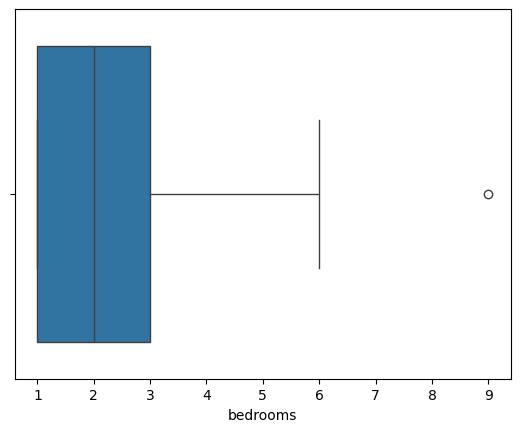

In [81]:
sns.boxplot(x=df["bedrooms"])


<Axes: xlabel='bedrooms', ylabel='Count'>

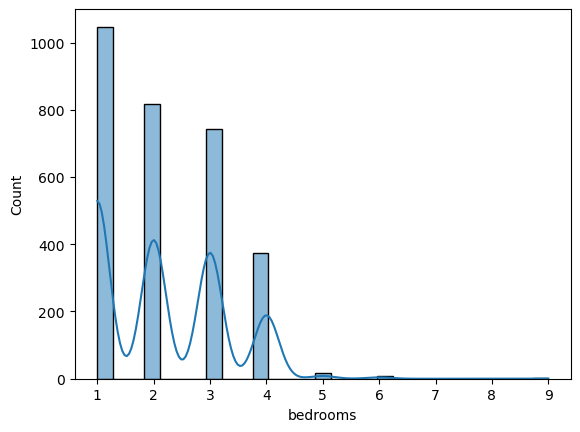

In [82]:
sns.histplot(df["bedrooms"], kde=True)


## bathrooms

<Axes: xlabel='baths', ylabel='Count'>

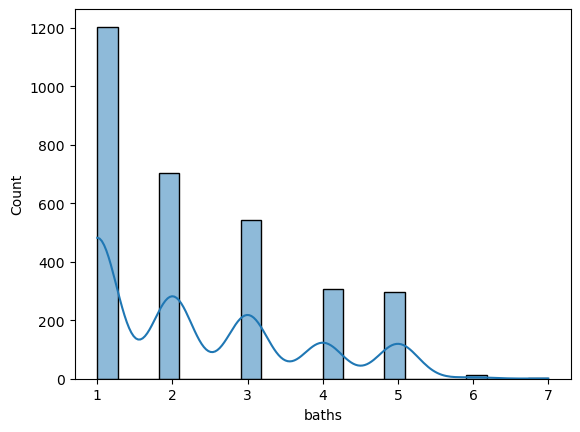

In [85]:
sns.histplot(df["baths"], kde=True)

<Axes: xlabel='baths'>

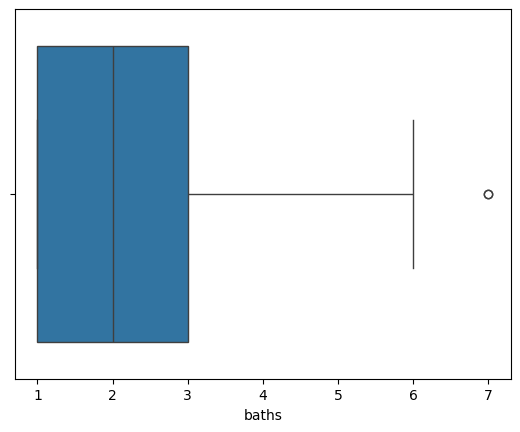

In [86]:
sns.boxplot(x=df["baths"])


## kitchens

<Axes: xlabel='kitchens', ylabel='Count'>

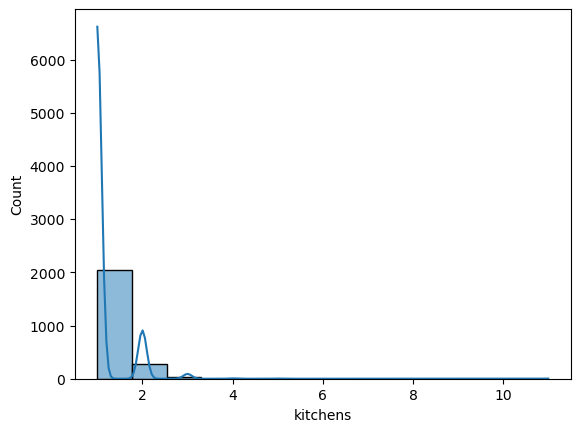

In [87]:
sns.histplot(df["kitchens"], kde=True)

<Axes: xlabel='kitchens'>

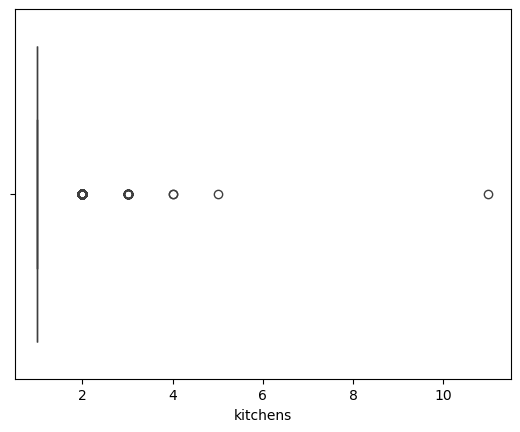

In [88]:
sns.boxplot(x=df["kitchens"])

In [97]:
df[df["kitchens"] > 3].sort_values("kitchens", ascending=False)

,property_id,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
519,1,Askari,4.0,5.0,https://www.zameen.com/Property/askari_10_aska...,9.0,4.5500,12.0,3264.0,1.0,4.0,1.0,13939.950980,1,1,1,1,1,1,1,1,1,1,170.0,39,NaN,New Property
2186,1,Raiwind Road,1.0,1.0,https://www.zameen.com/Property/al_kabir_town_...,10.0,0.6275,2.2,598.4,2.0,4.0,1.0,10486.296791,1,1,1,1,1,1,1,1,1,1,181.0,49,NaN,Relatively New


In [98]:
df = df.drop(index=[519, 2186])


<Axes: xlabel='kitchens'>

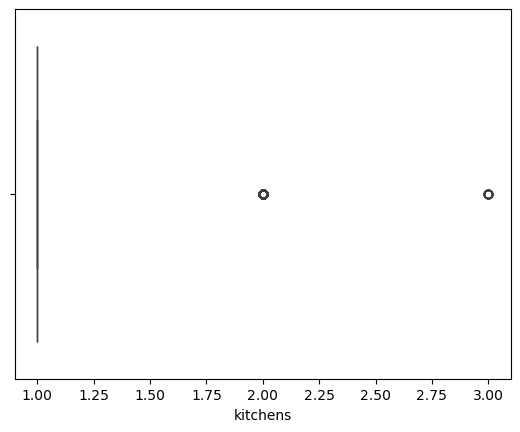

In [99]:
sns.boxplot(x=df["kitchens"])

In [100]:
df.shape

(3095, 27)

<Axes: xlabel='kitchens'>

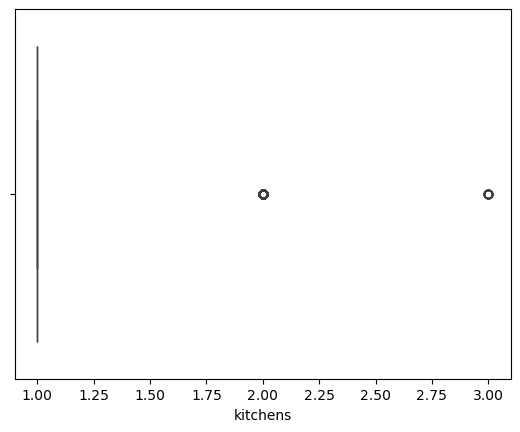

In [101]:
sns.boxplot(x=df["kitchens"])

<Axes: xlabel='kitchens', ylabel='Count'>

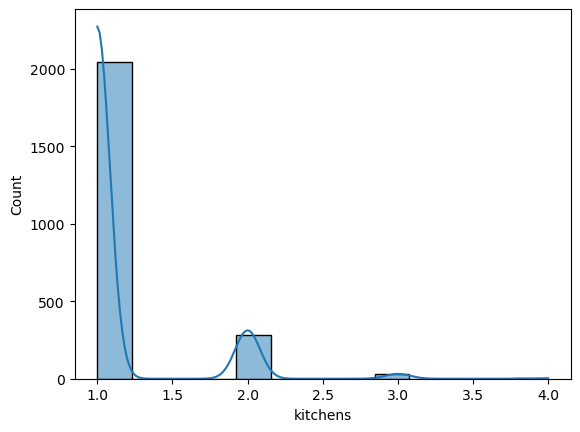

In [96]:
sns.histplot(df["kitchens"], kde=True)

In [102]:
df.columns

Index(['property_id', 'society', 'bedrooms', 'baths', 'link',
       'floors_in_building', 'price', 'area', 'area_sqft', 'servant_quarters',
       'kitchens', 'store_rooms', 'price_per_sqft', 'drawing_room',
       'dining_room', 'lounge_or_sitting_room', 'laundry_room', 'study_room',
       'prayer_room', 'powder_room', 'gym', 'steam_room', 'other_rooms',
       'luxury_score', 'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

## servant_quarters

<Axes: xlabel='servant_quarters', ylabel='Count'>

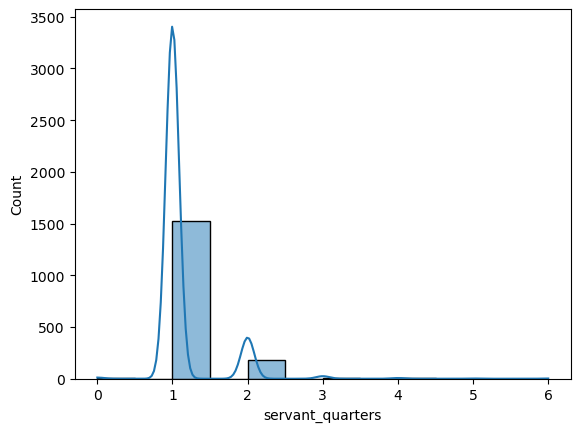

In [103]:
sns.histplot(df["servant_quarters"], kde=True)

<Axes: xlabel='servant_quarters'>

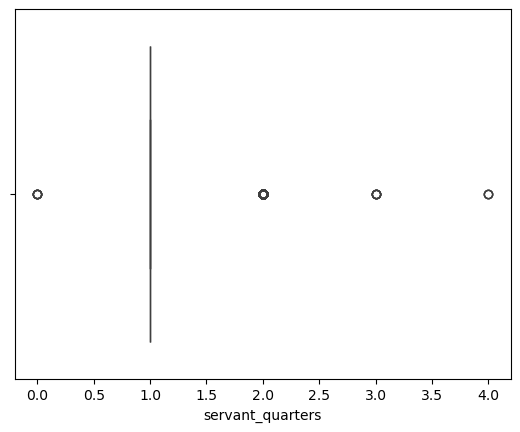

In [82]:
sns.boxplot(x=df["servant_quarters"])


In [104]:
s = df["servant_quarters"].dropna()
Q1, Q3 = s.quantile([0.25, 0.75])
IQR = Q3 - Q1
lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df["servant_quarters"] < lb) | (df["servant_quarters"] > ub)]
outliers[["servant_quarters", "price", "area", "society"]]


,servant_quarters,price,area,society
5,2.0,3.90,10.0,Askari
26,2.0,3.75,10.0,Askari
93,2.0,3.15,10.0,Askari
94,2.0,3.17,11.0,Askari
99,2.0,4.00,10.0,Askari
...,...,...,...,...
3055,2.0,1.35,3.7,Kacha Ferozepur Road
3057,2.0,0.35,1.5,Sabzazar Scheme
3061,2.0,0.30,2.0,GT Road
3072,2.0,1.35,4.1,Samanabad


In [ ]:
outliers.shape[0]

199

In [106]:
df.shape

(3095, 27)

In [107]:
df.isnull().sum()

property_id                  0
society                      0
bedrooms                    94
baths                       29
link                         0
floors_in_building        1438
price                        0
area                         0
area_sqft                    0
servant_quarters          1374
kitchens                   742
store_rooms               1346
price_per_sqft               0
drawing_room                 0
dining_room                  0
lounge_or_sitting_room       0
laundry_room                 0
study_room                   0
prayer_room                  0
powder_room                  0
gym                          0
steam_room                   0
other_rooms                  0
luxury_score                 0
furnishing_score             0
floor                     1132
agePossession                0
dtype: int64

## store_rooms      
- not checking bec too much null          

<Axes: xlabel='luxury_score', ylabel='Count'>

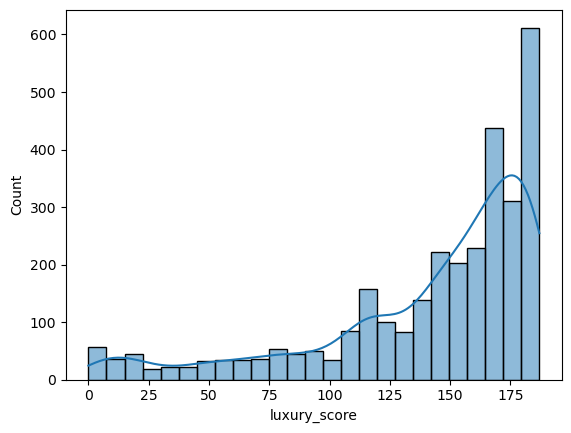

In [108]:
sns.histplot(df["luxury_score"], kde=True)

<Axes: xlabel='luxury_score'>

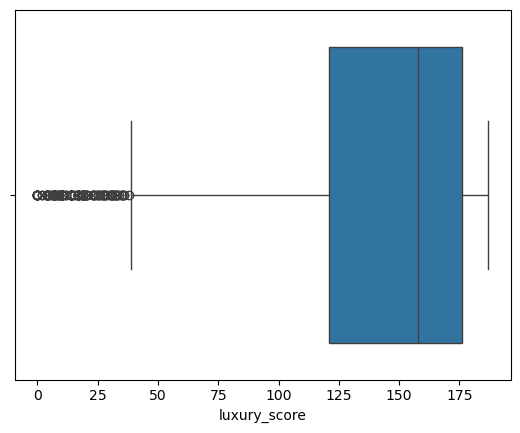

In [109]:
sns.boxplot(x=df["luxury_score"])

In [110]:
Q1 = df["luxury_score"].quantile(0.25)
Q3 = df["luxury_score"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR

df[df["luxury_score"] < lower_bound][["luxury_score", "society", "price"]]

,luxury_score,society,price
29,17.0,Askari,4.5000
55,31.0,Askari,4.2500
85,7.0,Askari,5.3000
86,7.0,Askari,3.3000
122,17.0,Askari,2.8700
...,...,...,...
3091,30.0,Lahore Villas,0.5162
3092,10.0,Lahore Villas,0.7500
3100,10.0,Pico Road,0.5500
3108,7.0,Wahdat Road,0.6500


<Axes: xlabel='price_per_sqft'>

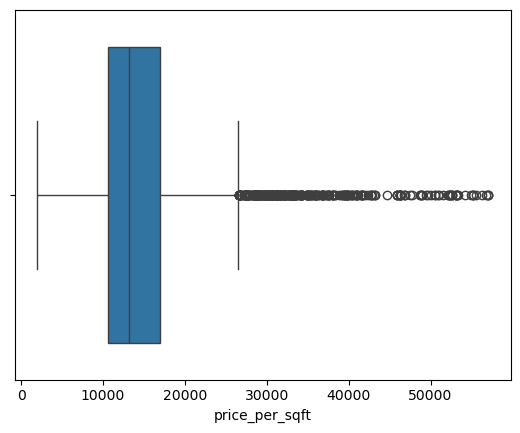

In [111]:
sns.boxplot(x=df["price_per_sqft"])

In [113]:
x = df[df["price_per_sqft"] <= 20000]
(x["area_sqft"] / x["bedrooms"]).quantile(0.05)

np.float64(353.6)

In [154]:
df.shape

(3042, 26)

In [156]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors_in_building', 'price',
       'area', 'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

In [158]:
x = df[df["price_per_sqft"] <= 20000]
(x["area_sqft"] / x["bedrooms"]).quantile(0.05)

np.float64(380.79999999999995)

In [163]:
df[(df["area_sqft"] / df["bedrooms"]) < 380.799]

,society,bedrooms,baths,link,floors_in_building,price,area,area_sqft,servant_quarters,kitchens,store_rooms,price_per_sqft,drawing_room,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,luxury_score,furnishing_score,floor,agePossession
978,Bahria Town,2.0,2.0,https://www.zameen.com/Property/bahria_town_ba...,NaN,0.7974,2.3,625.6,NaN,1.0,NaN,12746.163683,0,0,0,0,0,0,0,0,0,0,19.0,0,NaN,Undefined
1039,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_se...,7.0,0.4800,1.3,353.6,1.0,1.0,1.0,13574.660633,1,1,1,1,1,1,1,1,1,1,185.0,49,4,New Property
1043,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_ba...,NaN,0.4500,1.3,353.6,NaN,1.0,1.0,12726.244344,1,1,1,0,0,0,0,0,0,1,172.0,39,NaN,Relatively New
1048,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_ba...,NaN,0.5300,1.2,326.4,0.0,1.0,0.0,16237.745098,0,0,0,0,0,0,0,0,0,0,131.0,49,NaN,Undefined
1082,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_ba...,8.0,0.3800,1.3,353.6,1.0,1.0,1.0,10746.606335,0,1,1,0,0,0,0,0,0,0,173.0,49,2,New Property
1093,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_se...,4.0,0.4500,1.2,326.4,1.0,1.0,1.0,13786.764706,1,1,1,1,1,1,1,1,1,1,178.0,49,TRUE,Relatively New
1181,Bahria Town,1.0,NaN,https://www.zameen.com/Property/bahria_town_ba...,NaN,0.5300,1.2,326.4,1.0,NaN,2.0,16237.745098,1,1,1,1,1,1,1,1,1,1,148.0,49,NaN,Undefined
1223,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_ba...,8.0,0.5300,1.3,353.6,1.0,1.0,1.0,14988.687783,1,1,1,1,1,1,1,1,1,1,185.0,49,2,New Property
1224,Bahria Town,1.0,NaN,https://www.zameen.com/Property/bahria_town_ba...,NaN,0.5600,1.2,326.4,NaN,NaN,NaN,17156.862745,1,1,1,1,1,1,1,1,1,0,135.0,49,NaN,Undefined
1238,Bahria Town,1.0,1.0,https://www.zameen.com/Property/bahria_town_se...,NaN,0.3850,1.2,326.4,2.0,1.0,2.0,11795.343137,1,1,1,1,1,1,1,1,1,1,165.0,49,NaN,New Property


In [165]:
ratio = df["area_sqft"] / df["bedrooms"]
suspect = (df["bedrooms"] >= 4) & (ratio < 250)  # tune 250–300
df.loc[suspect, ["society","bedrooms","baths","area","area_sqft","link"]]
df = df.loc[~suspect].copy()


In [133]:
df.loc[1048]['link']

'https://www.zameen.com/Property/bahria_town_bahria_town_-_sector_b_best_price_apartment_available_for_sale_in_madina_heights_5_in_bahria_town_lahore-53781579-1772-1.html'

In [166]:
df.columns

Index(['society', 'bedrooms', 'baths', 'link', 'floors_in_building', 'price',
       'area', 'area_sqft', 'servant_quarters', 'kitchens', 'store_rooms',
       'price_per_sqft', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'luxury_score',
       'furnishing_score', 'floor', 'agePossession'],
      dtype='object')

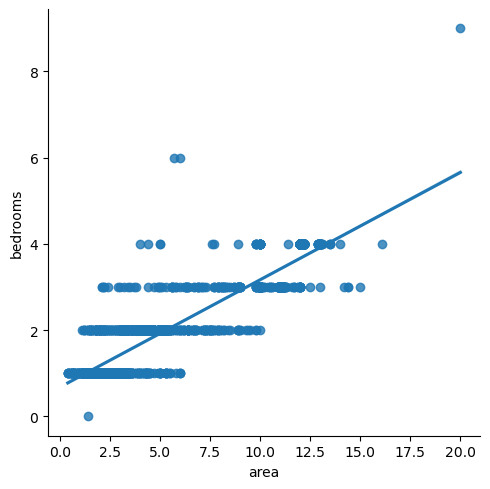

In [167]:
import seaborn as sns

sns.lmplot(data=df, x="area", y="bedrooms")


In [168]:
df.shape

(3034, 26)

In [171]:
df.to_csv("flats_outlier_treatment.csv")